In [ ]:
import pandas as pd
import os

# audio analysis
import librosa

# ml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# displaying spectrograms
import matplotlib.pyplot as plt
import librosa.display



## Importing the dataset from Kaggle  ##
This dataset contains 2500 wav files, 500 each for 5 different moods.The dataset is from kaggle.

In [ ]:
#!pip install kaggle


In [15]:
!kaggle datasets download -d auliayasmin/music-mood-classification


Dataset URL: https://www.kaggle.com/datasets/auliayasmin/music-mood-classification
License(s): unknown
100% 1.94G/1.95G [00:28<00:00, 99.4MB/s]
100% 1.95G/1.95G [00:28<00:00, 72.2MB/s]


In [16]:
!unzip music-mood-classification.zip


Archive:  music-mood-classification.zip
  inflating: dataset/aggressive/6761.wav  
  inflating: dataset/aggressive/6762.wav  
  inflating: dataset/aggressive/6763.wav  
  inflating: dataset/aggressive/6764.wav  
  inflating: dataset/aggressive/6765.wav  
  inflating: dataset/aggressive/6766.wav  
  inflating: dataset/aggressive/6767.wav  
  inflating: dataset/aggressive/6768.wav  
  inflating: dataset/aggressive/6769.wav  
  inflating: dataset/aggressive/6770.wav  
  inflating: dataset/aggressive/6771.wav  
  inflating: dataset/aggressive/6772.wav  
  inflating: dataset/aggressive/6773.wav  
  inflating: dataset/aggressive/6774.wav  
  inflating: dataset/aggressive/6775.wav  
  inflating: dataset/aggressive/6776.wav  
  inflating: dataset/aggressive/6777.wav  
  inflating: dataset/aggressive/6778.wav  
  inflating: dataset/aggressive/6799.wav  
  inflating: dataset/aggressive/6800.wav  
  inflating: dataset/aggressive/6801.wav  
  inflating: dataset/aggressive/6802.wav  
  inflating: d

## I will use the librosa library to analyze the .wav files

First I extract some simple features for the training of a random forest and an xgboost model.

In [18]:
dataset_path = 'dataset'

moods = ['aggressive', 'dramatic', 'happy', 'romantic', 'sad']
features = []
labels = []

In [19]:
def extract_features(file_path):
    ''' the function extract 4 features from a .wav file with librosa '''
    try:
        # load audio file
        y, sr = librosa.load(file_path, sr=None)

        # extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        # extract Chroma features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # extract Spectral Contrast features
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)

        # extract Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)

        # combine all features into a single array
        combined_features = np.hstack((mfcc_mean, chroma_mean, contrast_mean, zcr_mean))

        return combined_features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [20]:
# looping through the 5 mood folders and extracting + storing the 4 features from the first 100 songs (there are 500 in each folder but computational time)
for mood in moods:
    mood_folder = os.path.join(dataset_path, mood)
    # get the list of files and limit to the first 100
    files = os.listdir(mood_folder)[:100]
    for file_name in files:
        file_path = os.path.join(mood_folder, file_name)
        features.append(extract_features(file_path))
        labels.append(mood)

# convert to arrays
features = np.array(features)
labels = np.array(labels)



In [21]:
# print first 5 entries from features
print(features[:5])
# print first 5 according labels
print(labels[:5])

[[-1.36442612e+02  1.26640175e+02 -3.21495895e+01  2.84463940e+01
  -1.22866812e+01  2.89326668e+01 -1.38666475e+00  2.10033951e+01
   1.99650049e+00  1.02270193e+01 -3.84894699e-01  1.11350498e+01
   4.47448635e+00  3.91522378e-01  3.50768179e-01  3.74445051e-01
   5.05984187e-01  7.88793266e-01  6.68684304e-01  4.53156114e-01
   4.15621847e-01  4.20047671e-01  4.49755371e-01  3.78913164e-01
   3.86676311e-01  1.37077431e+01  9.86343471e+00  1.22998043e+01
   1.61769830e+01  1.47844011e+01  1.58013147e+01  4.29082965e+01
   5.97289189e-02]
 [-7.89337769e+01  9.22150879e+01 -1.56758010e+00  5.54355202e+01
  -8.49095058e+00  3.34533730e+01  3.26080394e+00  2.71819077e+01
  -8.32521439e-01  2.08356380e+01 -1.30858049e-01  1.49819012e+01
  -4.98060179e+00  7.77729928e-01  7.00040996e-01  6.20149732e-01
   6.00360334e-01  6.60485923e-01  6.61185801e-01  6.28182530e-01
   6.88312232e-01  7.19401717e-01  7.83167720e-01  7.61628091e-01
   7.44825125e-01  1.77967175e+01  9.93271289e+00  1.2218

In [ ]:

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)  # encoding moods as 0, 1, 2, etc.

## ML

In [23]:
X_train, X_test, y_train, y_test = train_test_split(features, encoded_labels, test_size=0.2, random_state=42)


Random Forest

In [ ]:


# train the random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# prediction and evaluation
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

  aggressive       0.96      0.89      0.93        28
    dramatic       0.69      0.79      0.73        14
       happy       0.64      0.90      0.75        10
    romantic       0.81      0.71      0.76        24
         sad       0.78      0.75      0.77        24

    accuracy                           0.80       100
   macro avg       0.78      0.81      0.79       100
weighted avg       0.81      0.80      0.80       100



XGBoost


In [ ]:
# training a simple xgboost model

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 80.00%


Now I start extracting mel spectorgrams for training a CNN model.

In [26]:
def extract_mel_spectrogram(file_path, n_mels=128):
    '''function to extract Mel Spectrograms without fixed size'''
    try:
        y, sr = librosa.load(file_path, sr=None)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db.T  # transpose to shape (time, features)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# preprocess the data
mel_features = []
mel_labels = []
for mood in moods:
    mood_folder = os.path.join(dataset_path, mood)
    files = os.listdir(mood_folder)[:100]
    processed_count = 0
    for file_name in files:
        file_path = os.path.join(mood_folder, file_name)
        mel_spec = extract_mel_spectrogram(file_path)
        if mel_spec is not None:
            mel_features.append(mel_spec)
            mel_labels.append(moods.index(mood))
            processed_count += 1
    print(f"Processed {processed_count} files for mood: {mood}")

# no need to convert mel_features to a NumPy arra, keep it as a list (my first model used np.array and it caused some difficulties)
# labels can still be a NumPy array
mel_labels = np.array(mel_labels)

# train test split
X_train, X_test, y_train, y_test = train_test_split(mel_features, mel_labels, test_size=0.2, random_state=42)

# Check the shapes
print(f"Number of training samples: {len(X_train)}")
print(f"Number of test samples: {len(X_test)}")


Processed 100 files for mood: aggressive
Processed 100 files for mood: dramatic
Processed 100 files for mood: happy
Processed 100 files for mood: romantic
Processed 100 files for mood: sad
Number of training samples: 400
Number of test samples: 100


In [ ]:

n_mels = 128  # number of Mel filter banks (used in feature extraction)
# defineing the model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(None, n_mels)),  # input shape (time, features)
    Conv1D(64, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(),  # handles variable-length inputs
    Dense(128, activation='relu'),
    Dense(len(moods), activation='softmax')
])

# compileing the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# pad sequences to ensure batch consistency
X_train_padded = pad_sequences(X_train, padding='post', dtype='float32')
X_test_padded = pad_sequences(X_test, padding='post', dtype='float32')

# add a channel dimension for Conv1D
X_train_padded = X_train_padded[..., np.newaxis]
X_test_padded = X_test_padded[..., np.newaxis]

# training
history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=30,
    batch_size=32
)

# evaluating
loss, accuracy = model.evaluate(X_test_padded, y_test)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.2235 - loss: 10.3316 - val_accuracy: 0.4600 - val_loss: 1.6721
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.2148 - loss: 2.1662 - val_accuracy: 0.3000 - val_loss: 1.5092
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2344 - loss: 1.7552 - val_accuracy: 0.5400 - val_loss: 1.3671
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3396 - loss: 1.4850 - val_accuracy: 0.4300 - val_loss: 1.4162
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3887 - loss: 1.4107 - val_accuracy: 0.4700 - val_loss: 1.2916
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4265 - loss: 1.3643 - val_accuracy: 0.4500 - val_loss: 1.2679
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3713 - loss: 1.5142 - val_accuracy: 0.4100 - val_loss: 1.5808
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3721 - loss: 1.4962 - val_accuracy: 0.4100 - 

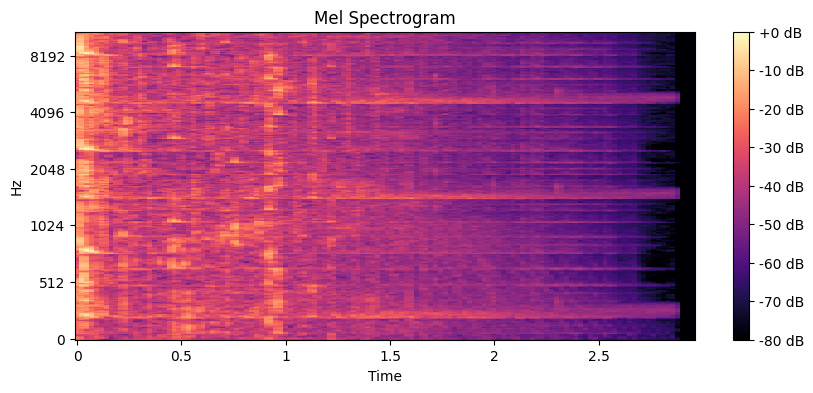

In [ ]:


# illustrating the first sample
mel_spec = mel_features[0]
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

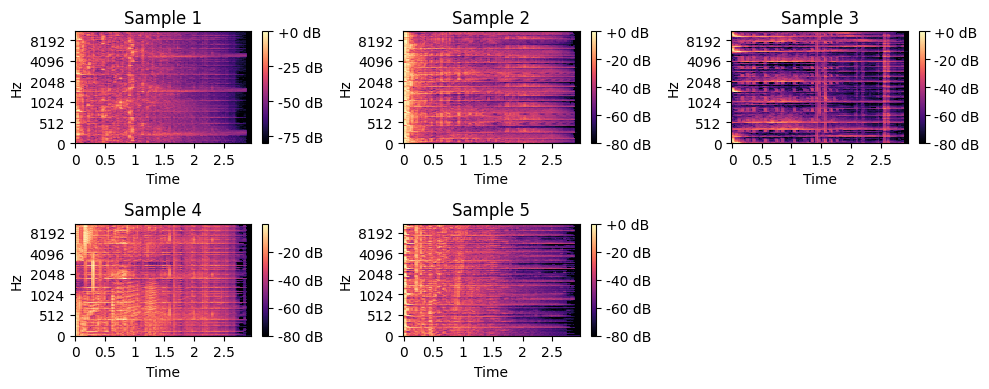

In [29]:
# illustrating some more just to make sure the CNN is working with meaningful data

plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(2, 3, i+1)
    mel_spec = mel_features[i]
    librosa.display.specshow(mel_spec, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Sample {i+1}')

plt.tight_layout()
plt.show()